In [10]:
import pandas as pd

# 1. Load the raw CSV files into Pandas DataFrames
orders = pd.read_csv("olist_orders_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")

print(f"Original Orders shape: {orders.shape}")

# 2. Join the Reviews to the Orders (linking them by order_id)
# We use a 'left' join to keep all orders, even if they don't have a review yet.
orders_reviews = pd.merge(orders, reviews, on='order_id', how='left')

# 3. Join the Customers to our new combined table (linking by customer_id)
master_data = pd.merge(orders_reviews, customers, on='customer_id', how='left')

# FIX: Drop duplicate orders caused by multiple reviews immediately
master_data = master_data.drop_duplicates(subset=['order_id'])

# 4. Check the final shape to make sure we didn't accidentally duplicate rows
print(f"Master Data shape: {master_data.shape}") # This will now perfectly match 99441!

# 5. Look at the first 3 rows of our new master table
master_data.head(3)

Original Orders shape: (99441, 8)
Master Data shape: (99441, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [11]:
# --- STORY 2: THE DELAY CALCULATOR ---

# 1. Convert the text dates into actual datetime objects
master_data['order_estimated_delivery_date'] = pd.to_datetime(master_data['order_estimated_delivery_date'])
master_data['order_delivered_customer_date'] = pd.to_datetime(master_data['order_delivered_customer_date'])

# 2. Handle missing values: filter out orders that were canceled or never delivered
delivered_orders = master_data.dropna(subset=['order_delivered_customer_date']).copy()

# 3. Calculate the difference in days (Actual Date - Estimated Date)
# If the number is positive, it arrived LATE. If negative, it arrived EARLY.
delivered_orders['Delay_Days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_estimated_delivery_date']).dt.days

# 4. Create a function to classify the delivery status
def classify_delivery(days_late):
    if days_late > 5:
        return "Super Late"
    elif days_late > 0:
        return "Late"
    else:
        return "On Time"

# Apply the function to create our new category column
delivered_orders['Delivery_Status'] = delivered_orders['Delay_Days'].apply(classify_delivery)

# 5. Let's see the results! How many packages were late?
print("\nDelivery Status Breakdown:")
print(delivered_orders['Delivery_Status'].value_counts())


Delivery Status Breakdown:
Delivery_Status
On Time       89941
Super Late     3765
Late           2770
Name: count, dtype: int64


/tmp/ipykernel_12974/2130742065.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_states, x='customer_state', y='Late_Percentage', palette='Reds_r')


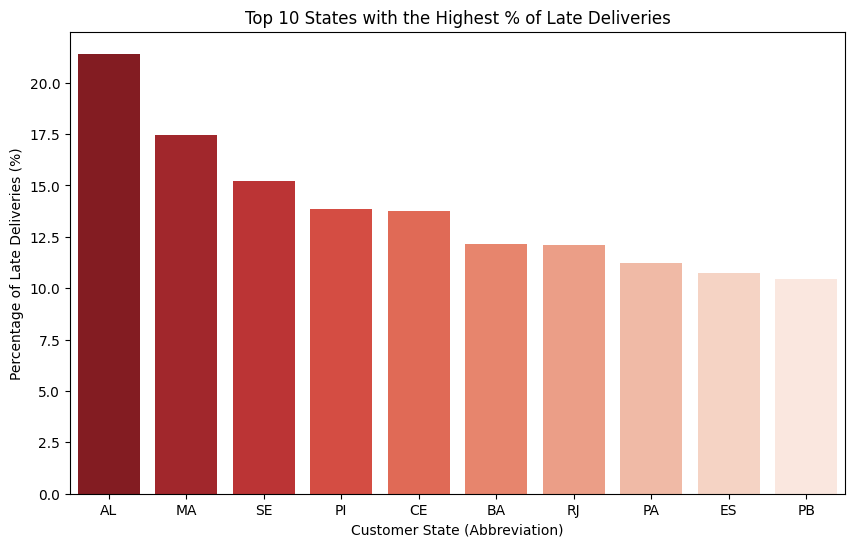

customer_state  Late_Percentage  Total_Orders
            AL        21.410579           397
            MA        17.433752           717
            SE        15.223881           335
            PI        13.865546           476
            CE        13.760751          1279
            BA        12.162162          3256
            RJ        12.102323         12353
            PA        11.205074           946
            ES        10.726817          1995
            PB        10.444874           517


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- STORY 3: GEOGRAPHIC ANALYSIS ---

# 1. Create a simple True/False column for whether an order was late
delivered_orders['Is_Late'] = delivered_orders['Delivery_Status'].isin(['Late', 'Super Late'])

# 2. Group by State to calculate total orders and late orders
state_stats = delivered_orders.groupby('customer_state').agg(
    Total_Orders=('order_id', 'count'),
    Late_Orders=('Is_Late', 'sum')
).reset_index()

# 3. Calculate the Percentage of Late Orders
state_stats['Late_Percentage'] = (state_stats['Late_Orders'] / state_stats['Total_Orders']) * 100

# 4. Filter out states with very few orders (e.g., less than 100) so outliers don't skew our chart
state_stats = state_stats[state_stats['Total_Orders'] > 100]

# 5. Sort to find the Top 10 worst offending states
worst_states = state_stats.sort_values('Late_Percentage', ascending=False).head(10)

# 6. Build the visual!
plt.figure(figsize=(10, 6))
sns.barplot(data=worst_states, x='customer_state', y='Late_Percentage', palette='Reds_r')
plt.title('Top 10 States with the Highest % of Late Deliveries')
plt.xlabel('Customer State (Abbreviation)')
plt.ylabel('Percentage of Late Deliveries (%)')
plt.show()

# Print the raw numbers below the chart
print(worst_states[['customer_state', 'Late_Percentage', 'Total_Orders']].to_string(index=False))

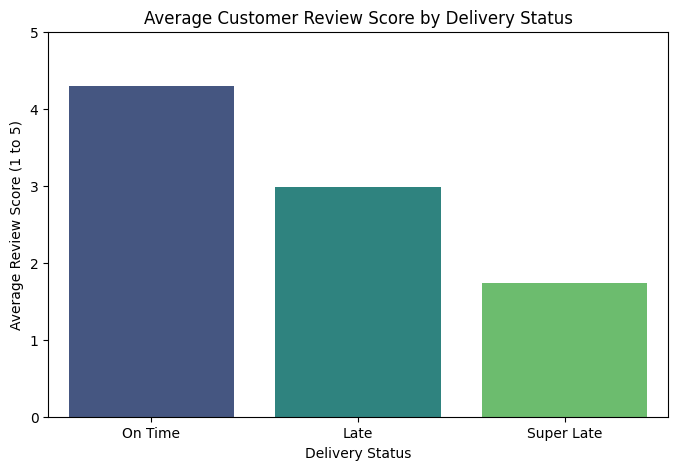


Average Review Scores:
Delivery_Status  review_score
        On Time      4.290582
           Late      2.988244
     Super Late      1.738798


In [13]:
# --- STORY 4: SENTIMENT CORRELATION ---

# 1. Clean the review data (drop rows where the customer didn't leave a score)
scored_orders = delivered_orders.dropna(subset=['review_score']).copy()

# 2. Calculate the average review score for each Delivery Status
status_scores = scored_orders.groupby('Delivery_Status')['review_score'].mean().reset_index()

# 3. Sort them logically for the chart
status_scores['Delivery_Status'] = pd.Categorical(
    status_scores['Delivery_Status'],
    categories=["On Time", "Late", "Super Late"],
    ordered=True
)
status_scores = status_scores.sort_values('Delivery_Status')

# 4. Build the visual! (I updated the code slightly to avoid that pink warning)
plt.figure(figsize=(8, 5))
sns.barplot(
    data=status_scores,
    x='Delivery_Status',
    y='review_score',
    hue='Delivery_Status',
    palette='viridis',
    legend=False
)
plt.title('Average Customer Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score (1 to 5)')
plt.ylim(0, 5) # Set Y-axis to max 5 stars so the scale makes sense
plt.show()

# Print the exact numbers
print("\nAverage Review Scores:")
print(status_scores.to_string(index=False))

In [14]:
# --- BONUS STORY: THE TRANSLATION CHALLENGE ---

# 1. Load the new bridge table
order_items = pd.read_csv("olist_order_items_dataset.csv")
# Load the products dataset and the translation table
products = pd.read_csv("olist_products_dataset.csv")
translations = pd.read_csv("product_category_name_translation.csv")

# 2. Join the products table with the English translations
products_english = pd.merge(products, translations, on='product_category_name', how='left')

# 3. Join our delivered_orders to the order_items bridge table
orders_with_items = pd.merge(delivered_orders, order_items, on='order_id', how='left')

# 4. Finally, join that massive table to our translated products table
full_logistics_data = pd.merge(orders_with_items, products_english, on='product_id', how='left')

# 5. Let's see which English product categories have the highest number of LATE deliveries!
late_products = full_logistics_data[full_logistics_data['Is_Late'] == True]
worst_categories = late_products['product_category_name_english'].value_counts().head(5)

print("Top 5 Product Categories with the Most Late Deliveries:")
print(worst_categories)

Top 5 Product Categories with the Most Late Deliveries:
product_category_name_english
bed_bath_table           770
health_beauty            717
furniture_decor          574
sports_leisure           532
computers_accessories    496
Name: count, dtype: int64


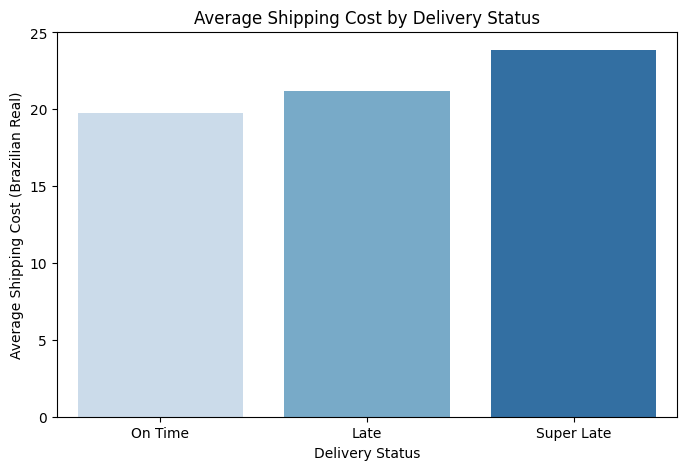


Average Shipping Cost:
Delivery_Status  freight_value
        On Time      19.753684
           Late      21.178924
     Super Late      23.855786


In [15]:
# --- STORY 6: CANDIDATE'S CHOICE (SHIPPING COST ANALYSIS) ---
# Question: Are customers paying higher freight costs for packages that end up being late?

# 1. Calculate the average freight value for On Time vs Late/Super Late orders
freight_analysis = full_logistics_data.groupby('Delivery_Status')['freight_value'].mean().reset_index()

# 2. Sort logically for the chart
freight_analysis['Delivery_Status'] = pd.Categorical(
    freight_analysis['Delivery_Status'],
    categories=["On Time", "Late", "Super Late"],
    ordered=True
)
freight_analysis = freight_analysis.sort_values('Delivery_Status')

# 3. Build the visual!
plt.figure(figsize=(8, 5))
sns.barplot(
    data=freight_analysis,
    x='Delivery_Status',
    y='freight_value',
    hue='Delivery_Status',
    palette='Blues',
    legend=False
)
plt.title('Average Shipping Cost by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Shipping Cost (Brazilian Real)')
plt.show()

# Print the exact numbers
print("\nAverage Shipping Cost:")
print(freight_analysis.to_string(index=False))

In [16]:
# Save our master dataset to a single CSV for Looker Studio
full_logistics_data.to_csv('veridi_clean_logistics.csv', index=False)
print("Data exported successfully! Check the file folder on the left.")

Data exported successfully! Check the file folder on the left.
